---
# Part II – Tweets Emotion Classification using Word Embeddings

In [ ]:
import pandas as pd
import numpy as np
import gensim.downloader as gensim_api
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [4]:
twdataset = pd.read_csv('twitter_emotion.csv')
print(twdataset.shape)
print(twdataset.head())

(416809, 3)
   Unnamed: 0                                               text  label
0           0      i just feel really helpless and heavy hearted      4
1           1  ive enjoyed being able to slouch about relax a...      0
2           2  i gave up my internship with the dmrg and am f...      4
3           3                         i dont know i feel so lost      0
4           4  i am a kindergarten teacher and i am thoroughl...      4


In [5]:
TWTEXTCOL  = twdataset.columns[0] 
TWLABELCOL = twdataset.columns[-1] 
print(f'Text column : {TWTEXTCOL}')
print(f'Label column: {TWLABELCOL}')
print('\nEmotion distribution:')
print(twdataset[TWLABELCOL].value_counts())

Text column : Unnamed: 0
Label column: label

Emotion distribution:
label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64


## 1. Tweets Pre-processing – Keras Tokenizer

In [ ]:
MAX_WORDS  = 100_000
MAX_SEQ_LEN = 500         
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(twdataset[TWTEXTCOL].astype(str))
sequences = tokenizer.texts_to_sequences(twdataset[TWTEXTCOL].astype(str))
word_index = tokenizer.word_index
print(f'Vocab size        : {len(word_index)}')
print(f'First 10 entries  : {list(word_index.items())[:10]}')
padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_SEQ_LEN,
    padding='post',
    truncating='post'
)
print(f'Padded sequences shape: {padded_sequences.shape}')

Vocab size        : 416810
First 10 entries  : [('<OOV>', 1), ('0', 2), ('1', 3), ('2', 4), ('3', 5), ('4', 6), ('5', 7), ('6', 8), ('7', 9), ('8', 10)]
Padded sequences shape: (416809, 50)


## 2a. Pre-trained Embeddings – GloVe Twitter 50d

In [7]:
glove_model = gensim_api.load('glove-twitter-50')
EMBEDDING_DIM_GLOVE = 50
print(f'Vocabulary size in GloVe model: {len(glove_model.key_to_index)}')

Vocabulary size in GloVe model: 1193514


In [8]:
def buildEmbeddingMatrix(wvModel, word_index, max_words, embedding_dimension):
    matrix = np.zeros((max_words + 1, embedding_dimension))
    for word, idx in word_index.items():
        if idx > max_words:
            continue
        try:
            matrix[idx] = wvModel[word]
        except KeyError:
            pass   
    return matrix
glove_embedding_matrix = buildEmbeddingMatrix(
    glove_model, word_index, MAX_WORDS, EMBEDDING_DIM_GLOVE
)
print(f'GloVe embedding matrix shape: {glove_embedding_matrix.shape}')

GloVe embedding matrix shape: (100001, 50)


## 2b. Your trained word2vec model word embeddings:

In [23]:
print("Step 2b – Training custom Word2Vec model …")

indx_to_word = {idx: word for word, idx in word_index.items()}
tokenized_tweets = [
    [indx_to_word[idx] for idx in seq if idx in indx_to_word]
    for seq in sequences
]

print(f"Total tokenized tweets : {len(tokenized_tweets)}")
print(f"First tokenized tweet  : {tokenized_tweets[0]}")

w2v_model = Word2Vec(
    sentences=tokenized_tweets,
    vector_size=100,
    window=5,
    min_count=1,
    epochs=10,
    sg=1
)

w2v_model.save("word2vec_twitter.model")
print(f"Word2Vec size : {len(w2v_model.wv.key_to_index)}")

print("Building Word2Vec embedding matrix")
w2v_embedding_matrix = buildEmbeddingMatrix(
    w2v_model.wv, word_index, MAX_WORDS, 100
)
print(f"Word2Vec embedding matrix shape: {w2v_embedding_matrix.shape}")

Step 2b – Training custom Word2Vec model …
Total tokenized tweets : 416809
First tokenized tweet  : ['0']
Word2Vec size : 99999
Building Word2Vec embedding matrix
Word2Vec embedding matrix shape: (100001, 100)


## 3. Data preparation and splitting:

3a. Apply one-hot encoding for the integer labels using keras.

In [29]:
from tensorflow.keras.utils import to_categorical

labels = twdataset[TWLABELCOL].values
one_hot_labels = to_categorical(labels)

print("Original labels shape:", labels.shape)
print("One-hot labels shape:", one_hot_labels.shape)

Original labels shape: (416809,)
One-hot labels shape: (416809, 6)


3b. Splitting


In [31]:
from sklearn.model_selection import train_test_split

# split 80% & 20%

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    padded_sequences,       # input features
    one_hot_labels,         # labels
    test_size=0.2,          # 20% test
    random_state=42,        
    shuffle=True
)

print("\n80/20 Split:")
print("X_train shape:", X_train_80.shape)
print("X_test shape :", X_test_80.shape)


# split 70% & 30%

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    padded_sequences,
    one_hot_labels,
    test_size=0.3,          
    random_state=42,
    shuffle=True
)

print("\n70/30 Split:")
print("X_train shape:", X_train_70.shape)
print("X_test shape :", X_test_70.shape)


80/20 Split:
X_train shape: (333447, 50)
X_test shape : (83362, 50)

70/30 Split:
X_train shape: (291766, 50)
X_test shape : (125043, 50)


4.1 — Model Builder Function

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

NUM_CLASSES = one_hot_labels.shape[1]       # 6
MAX_LEN     = padded_sequences.shape[1]     # your padding length from Part 1

def build_cnn_model(embedding_matrix, embedding_dim, name="CNN"):
    """
    Architecture:
      - Embedding layer    (frozen, pre-trained weights)
      - Conv1D  128 filters, kernel 5
      - Conv1D  64  filters, kernel 3
      - Output  Dense 6, softmax
    """
    vocab_size = embedding_matrix.shape[0]

    model = Sequential(name=name)
    
    # ── Input layer (forces the model to build all layers) ──
    model.add(Input(shape=(MAX_LEN,)))

    # Embedding layer
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ))

    # 1st Conv1D layer
    model.add(Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'))
    model.add(Dropout(0.3))

    # 2nd Conv1D layer
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(GlobalMaxPooling1D())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

4.2 — Training & Plotting Helpers

In [42]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test,
                       epochs=15, batch_size=128):

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n★ Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}\n")
    return history, test_loss, test_acc


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['accuracy'],    label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history.history['loss'],    label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout(); plt.show()

4.3 — Run All 4 Experiments

  GloVe-50d  |  80/20 Split


Model: "CNN_GloVe_80_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 50)         │     5,000,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 50, 128)        │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 50, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057,208 (19.29 MB)

 Trainable params: 5,057,208 (19.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 135s 57ms/step - accuracy: 0.3388 - loss: 1.6073 - val_accuracy: 0.3372 - val_loss: 1.5772
Epoch 2/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 1214s 518ms/step - accuracy: 0.3387 - loss: 1.5720 - val_accuracy: 0.3372 - val_loss: 1.5762
Epoch 3/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 118s 50ms/step - accuracy: 0.3387 - loss: 1.5719 - val_accuracy: 0.3372 - val_loss: 1.5761
Epoch 4/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 120s 51ms/step - accuracy: 0.3387 - loss: 1.5719 - val_accuracy: 0.3372 - val_loss: 1.5761
Epoch 5/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 113s 48ms/step - accuracy: 0.3387 - loss: 1.5719 - val_accuracy: 0.3372 - val_loss: 1.5762
Epoch 6/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 115s 49ms/step - accuracy: 0.3387 - loss: 1.5719 - val_accuracy: 0.3372 - val_loss: 1.5762

★ Test Loss: 1.5745  |  Test Accuracy: 0.3379



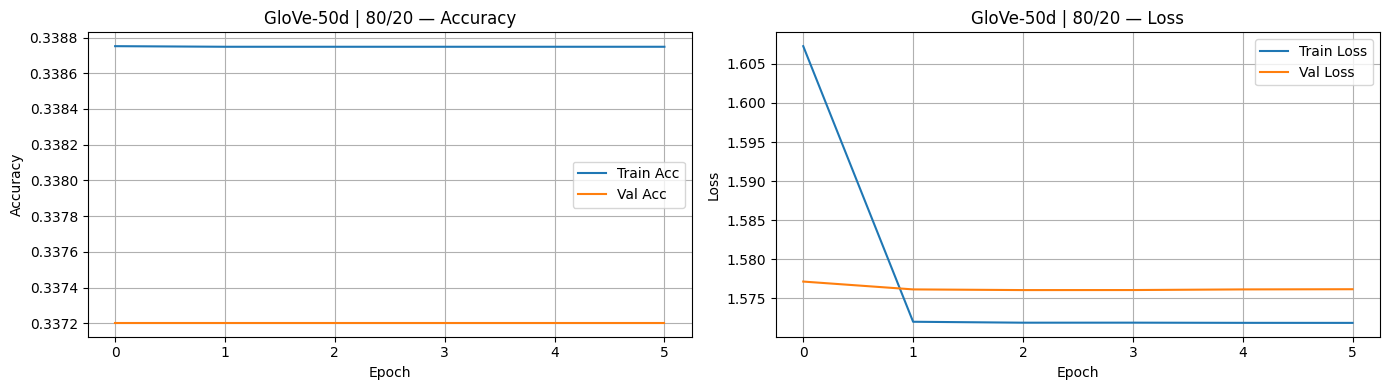

  GloVe-50d  |  70/30 Split
Epoch 1/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 100s 48ms/step - accuracy: 0.3382 - loss: 1.6125 - val_accuracy: 0.3382 - val_loss: 1.5777
Epoch 2/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 96s 47ms/step - accuracy: 0.3387 - loss: 1.5719 - val_accuracy: 0.3382 - val_loss: 1.5761
Epoch 3/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 100s 49ms/step - accuracy: 0.3387 - loss: 1.5715 - val_accuracy: 0.3382 - val_loss: 1.5760
Epoch 4/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 95s 46ms/step - accuracy: 0.3387 - loss: 1.5715 - val_accuracy: 0.3382 - val_loss: 1.5760
Epoch 5/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 100s 49ms/step - accuracy: 0.3387 - loss: 1.5715 - val_accuracy: 0.3382 - val_loss: 1.5760
Epoch 6/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 98s 48ms/step - accuracy: 0.3387 - loss: 1.5715 - val_accuracy: 0.3382 - val_loss: 1.5760
Epoch 7/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 100s 49ms/step - accuracy: 0.3387 - loss: 1.5715 - val_accuracy: 0.3382 - val_loss: 1.5760

★ Test Loss: 1.5745  |  Test Accuracy: 0.33

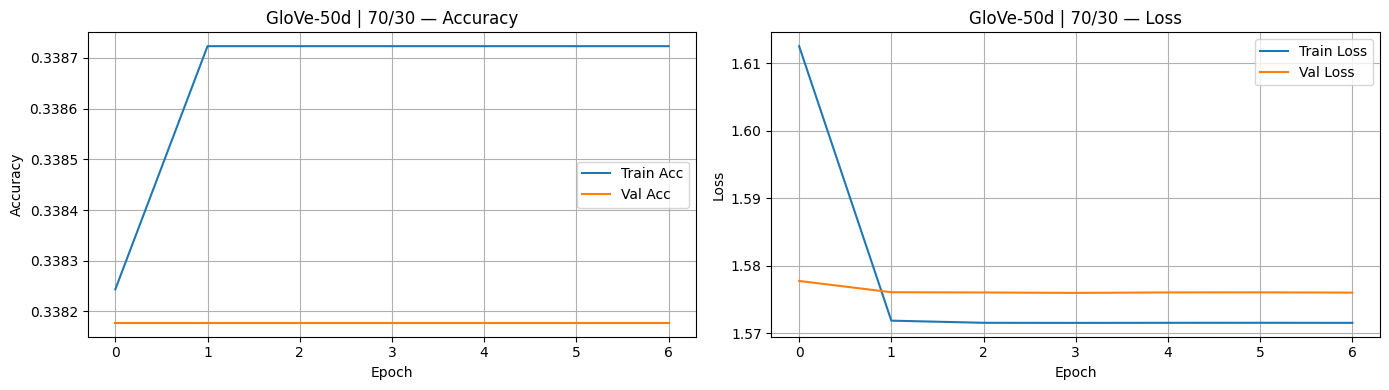

  Word2Vec-100d  |  80/20 Split


Model: "CNN_W2V_80_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 50, 100)        │    10,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 50, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 50, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,089,258 (38.49 MB)

 Trainable params: 10,089,258 (38.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 221s 94ms/step - accuracy: 0.3360 - loss: 1.5779 - val_accuracy: 0.3372 - val_loss: 1.5811
Epoch 2/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 228s 97ms/step - accuracy: 0.3475 - loss: 1.5481 - val_accuracy: 0.3365 - val_loss: 1.5778
Epoch 3/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 230s 98ms/step - accuracy: 0.4326 - loss: 1.3484 - val_accuracy: 0.3292 - val_loss: 1.5782
Epoch 4/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 227s 97ms/step - accuracy: 0.4820 - loss: 1.2351 - val_accuracy: 0.3371 - val_loss: 1.5801
Epoch 5/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 225s 96ms/step - accuracy: 0.4952 - loss: 1.2018 - val_accuracy: 0.3372 - val_loss: 1.5773
Epoch 6/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 220s 94ms/step - accuracy: 0.4972 - loss: 1.1964 - val_accuracy: 0.3339 - val_loss: 1.5819
Epoch 7/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 221s 94ms/step - accuracy: 0.4970 - loss: 1.1965 - val_accuracy: 0.3295 - val_loss: 1.5896
Epoch 8/15
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 225s 96ms/step - accuracy: 

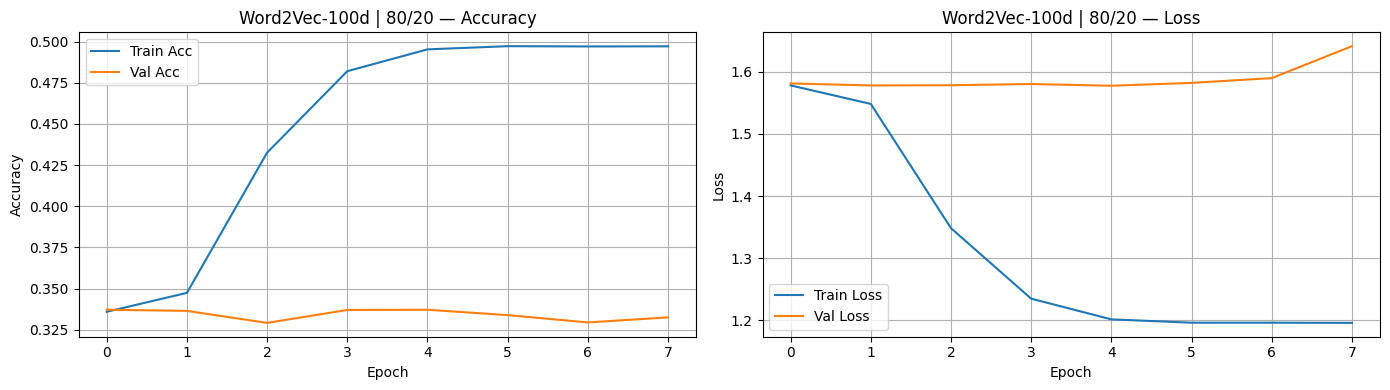

  Word2Vec-100d  |  70/30 Split
Epoch 1/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 197s 96ms/step - accuracy: 0.3354 - loss: 1.5784 - val_accuracy: 0.3382 - val_loss: 1.5795
Epoch 2/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 194s 95ms/step - accuracy: 0.3719 - loss: 1.4998 - val_accuracy: 0.3364 - val_loss: 1.5825
Epoch 3/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 199s 97ms/step - accuracy: 0.4631 - loss: 1.2822 - val_accuracy: 0.3382 - val_loss: 1.5828
Epoch 4/15
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 195s 95ms/step - accuracy: 0.4952 - loss: 1.2024 - val_accuracy: 0.3380 - val_loss: 1.5834

★ Test Loss: 1.5781  |  Test Accuracy: 0.3379



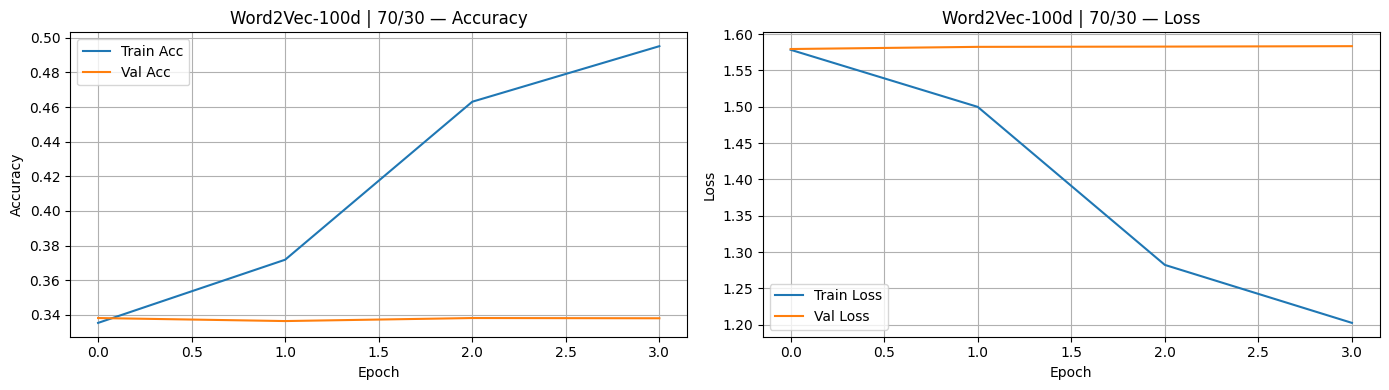

In [43]:
results = {}

# ═══════════════════════════════════════════════════════
#  MODEL 1 — GloVe Embeddings (50d)
# ═══════════════════════════════════════════════════════

# ── GloVe + 80/20 ──
print("=" * 60)
print("  GloVe-50d  |  80/20 Split")
print("=" * 60)
model_glove_80 = build_cnn_model(glove_embedding_matrix, EMBEDDING_DIM_GLOVE, name="CNN_GloVe_80_20")
model_glove_80.summary()
hist, loss, acc = train_and_evaluate(model_glove_80, X_train_80, X_test_80, y_train_80, y_test_80)
plot_history(hist, "GloVe-50d | 80/20")
results["GloVe-50d | 80/20"] = {"loss": loss, "accuracy": acc}

# ── GloVe + 70/30 ──
print("=" * 60)
print("  GloVe-50d  |  70/30 Split")
print("=" * 60)
model_glove_70 = build_cnn_model(glove_embedding_matrix, EMBEDDING_DIM_GLOVE, name="CNN_GloVe_70_30")
hist, loss, acc = train_and_evaluate(model_glove_70, X_train_70, X_test_70, y_train_70, y_test_70)
plot_history(hist, "GloVe-50d | 70/30")
results["GloVe-50d | 70/30"] = {"loss": loss, "accuracy": acc}

# ═══════════════════════════════════════════════════════
#  MODEL 2 — Word2Vec Embeddings (100d)
# ═══════════════════════════════════════════════════════

# ── Word2Vec + 80/20 ──
print("=" * 60)
print("  Word2Vec-100d  |  80/20 Split")
print("=" * 60)
model_w2v_80 = build_cnn_model(w2v_embedding_matrix, EMBEDDING_DIM_W2V, name="CNN_W2V_80_20")
model_w2v_80.summary()
hist, loss, acc = train_and_evaluate(model_w2v_80, X_train_80, X_test_80, y_train_80, y_test_80)
plot_history(hist, "Word2Vec-100d | 80/20")
results["Word2Vec-100d | 80/20"] = {"loss": loss, "accuracy": acc}

# ── Word2Vec + 70/30 ──
print("=" * 60)
print("  Word2Vec-100d  |  70/30 Split")
print("=" * 60)
model_w2v_70 = build_cnn_model(w2v_embedding_matrix, EMBEDDING_DIM_W2V, name="CNN_W2V_70_30")
hist, loss, acc = train_and_evaluate(model_w2v_70, X_train_70, X_test_70, y_train_70, y_test_70)
plot_history(hist, "Word2Vec-100d | 70/30")
results["Word2Vec-100d | 70/30"] = {"loss": loss, "accuracy": acc}

4.4 — Results Comparison Table

In [45]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df.index.name = "Experiment"
results_df = results_df.round(4)
print("\n")
print(results_df.to_string())



                         loss  accuracy
Experiment                             
GloVe-50d | 80/20      1.5745    0.3379
GloVe-50d | 70/30      1.5745    0.3379
Word2Vec-100d | 80/20  1.5756    0.3379
Word2Vec-100d | 70/30  1.5781    0.3379
